# Part C: Deep Learning — LSTM & CNN+LSTM Forecasting
## Smart Energy Forecasting & Anomaly Detection
**Objective**: Build LSTM and CNN+LSTM models in PyTorch for multi-step energy forecasting.
**Framework**: PyTorch ONLY (no Keras/TensorFlow)

In [2]:
# === IMPORTS ===

# Standard
import os, time, warnings
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Utilities
from datetime import datetime
import math

In [3]:
# === GLOBAL CONSTANTS & REPRODUCIBILITY ===
TARGET = 'Appliances'
INPUT_STEPS  = 48   # 8 hours of input
OUTPUT_STEPS = 6    # 1 hour forecast horizon
RANDOM_STATE = 42

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cpu


## Load Feature-Engineered Data

In [4]:
df_feat = pd.read_csv('df_engineered.csv', index_col='date', parse_dates=True)
df_feat = df_feat.sort_index()

print(f"Dataset shape: {df_feat.shape}")

Dataset shape: (19687, 60)


### 1. Chronological Train/Validation/Test Split

**Splitting Strategy:**
We split the dataset strictly chronologically — train on the earliest 70%, validate on the
next 15%, and test on the final 15%. This mirrors real deployment: models are always trained
on historical data and evaluated on future data. Any form of shuffling would cause data
leakage, allowing the model to see future patterns during training and producing falsely
optimistic evaluation metrics.

The validation set is used for early stopping and threshold determination (Part D).
The test set is untouched until final evaluation.

In [5]:
n = len(df_feat)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_train = df_feat.iloc[:train_end]
df_val   = df_feat.iloc[train_end:val_end]
df_test  = df_feat.iloc[val_end:]

print(f"Train: {df_train.index[0]} → {df_train.index[-1]} ({len(df_train)} rows)")
print(f"Val:   {df_val.index[0]}   → {df_val.index[-1]}   ({len(df_val)} rows)")
print(f"Test:  {df_test.index[0]}  → {df_test.index[-1]}  ({len(df_test)} rows)")

Train: 2016-01-12 01:00:00 → 2016-04-16 17:30:00 (13780 rows)
Val:   2016-04-16 17:40:00   → 2016-05-07 05:40:00   (2953 rows)
Test:  2016-05-07 05:50:00  → 2016-05-27 18:00:00  (2954 rows)


In [6]:
# === FEATURE SELECTION FOR DEEP LEARNING ===
# Drop noise and highly redundant features
drop_cols = ['rv1', 'rv2']
feature_cols = [c for c in df_feat.columns if c not in [TARGET] + drop_cols]

# Input features (multivariate: all features including other sensors)
X_cols = feature_cols
y_col  = TARGET

print(f"Number of input features: {len(X_cols)}")
print(f"Input features: {X_cols}")

Number of input features: 57
Input features: ['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'dayofweek', 'month', 'is_weekend', 'is_peak_hour', 'is_night', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'lag_1', 'lag_2', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_48', 'rolling_std_48', 'T_indoor_avg', 'T_diff_in_out', 'T_indoor_range', 'T6_T_out_diff', 'RH_indoor_avg', 'RH_diff_in_out', 'heat_index_proxy', 'lights_x_hour']


### Scaling

**Scaler Choice: StandardScaler (Z-score normalization)**

We use StandardScaler because:
1. Energy consumption and sensor readings are not bounded — MinMaxScaler would be distorted
   by outlier spikes, compressing the rest of the data into a narrow range.
2. LSTMs and CNNs are sensitive to input scale; zero-mean, unit-variance inputs lead to
   more stable gradients.
3. StandardScaler is fit ONLY on training data and applied to validation and test sets
   — this prevents any information from future data influencing the normalization.

We scale X (features) and y (target) separately so we can inverse-transform predictions.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit on train only
X_train_scaled = scaler_X.fit_transform(df_train[X_cols])
X_val_scaled   = scaler_X.transform(df_val[X_cols])
X_test_scaled  = scaler_X.transform(df_test[X_cols])

y_train_scaled = scaler_y.fit_transform(df_train[[y_col]]).flatten()
y_val_scaled   = scaler_y.transform(df_val[[y_col]]).flatten()
y_test_scaled  = scaler_y.transform(df_test[[y_col]]).flatten()

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train_scaled range: {y_train_scaled.min():.2f} to {y_train_scaled.max():.2f}")

X_train_scaled shape: (13780, 57)
y_train_scaled range: -0.83 to 9.16


### Sliding Window Sequences

In [8]:
def create_sequences(X, y, input_steps, output_steps):
    """
    Creates (X_seq, y_seq) pairs from time series using a sliding window.

    X_seq shape: (num_samples, input_steps, num_features)
    y_seq shape: (num_samples, output_steps)

    The window slides one step at a time. For each window:
    - Input:  X[i : i+input_steps]                         (48 steps of all features)
    - Target: y[i+input_steps : i+input_steps+output_steps] (next 6 steps of target only)
    """
    X_seqs, y_seqs = [], []
    total = len(X) - input_steps - output_steps + 1

    for i in range(total):
        X_seqs.append(X[i : i + input_steps])
        y_seqs.append(y[i + input_steps : i + input_steps + output_steps])

    return np.array(X_seqs, dtype=np.float32), np.array(y_seqs, dtype=np.float32)


X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, INPUT_STEPS, OUTPUT_STEPS)
X_val_seq,   y_val_seq   = create_sequences(X_val_scaled,   y_val_scaled,   INPUT_STEPS, OUTPUT_STEPS)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test_scaled,  INPUT_STEPS, OUTPUT_STEPS)

print(f"Train sequences: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"Val   sequences: X={X_val_seq.shape},   y={y_val_seq.shape}")
print(f"Test  sequences: X={X_test_seq.shape},  y={y_test_seq.shape}")

Train sequences: X=(13727, 48, 57), y=(13727, 6)
Val   sequences: X=(2900, 48, 57),   y=(2900, 6)
Test  sequences: X=(2901, 48, 57),  y=(2901, 6)


### Custom PyTorch Dataset & DataLoader

In [9]:
class EnergyDataset(Dataset):
    """
    Custom PyTorch Dataset for multivariate time-series energy data.

    Args:
        X (np.ndarray): Input sequences of shape (num_samples, input_steps, num_features)
        y (np.ndarray): Target sequences of shape (num_samples, output_steps)
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Create Dataset objects
train_dataset = EnergyDataset(X_train_seq, y_train_seq)
val_dataset   = EnergyDataset(X_val_seq,   y_val_seq)
test_dataset  = EnergyDataset(X_test_seq,  y_test_seq)

# Create DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")

# Sanity check — verify one batch
sample_X, sample_y = next(iter(train_loader))
print(f"\nSample batch X shape: {sample_X.shape}")  # Expected: (64, 48, num_features)
print(f"Sample batch y shape: {sample_y.shape}")    # Expected: (64, 6)

Train batches: 215
Val   batches: 46
Test  batches: 46

Sample batch X shape: torch.Size([64, 48, 57])
Sample batch y shape: torch.Size([64, 6])


### Visualize a Sample Window

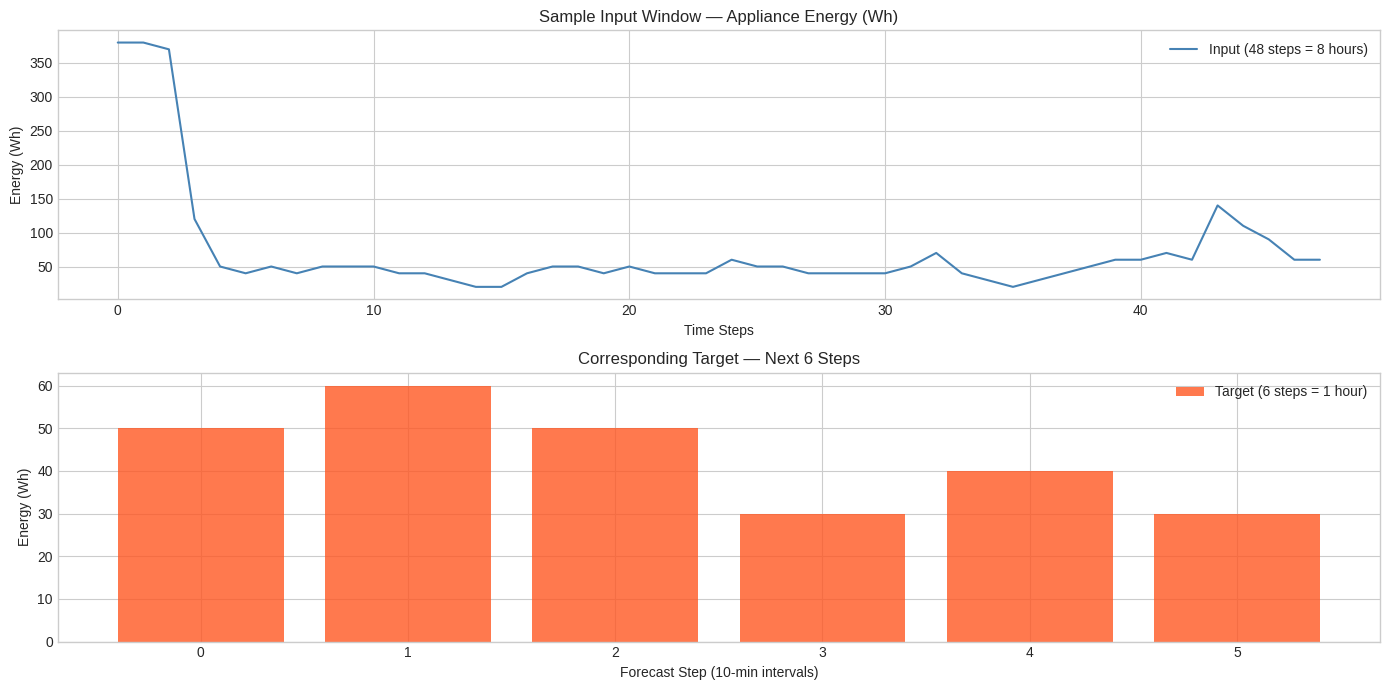

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Find the index of Appliances-related feature in X_cols (if present)
# Since Appliances is the target (not in X_cols), we use the first lag feature or first column
app_idx = 0  # default to first feature
for i, col in enumerate(X_cols):
    if 'lag_1' in col:
        app_idx = i
        break

sample_input  = X_train_seq[0, :, app_idx]
sample_target = y_train_seq[0, :]

# Inverse transform for readable Wh values
sample_input_wh  = scaler_y.inverse_transform(sample_input.reshape(-1, 1)).flatten()
sample_target_wh = scaler_y.inverse_transform(sample_target.reshape(-1, 1)).flatten()

axes[0].plot(range(INPUT_STEPS), sample_input_wh, color='steelblue', linewidth=1.5, label='Input (48 steps = 8 hours)')
axes[0].set_title('Sample Input Window — Appliance Energy (Wh)')
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Energy (Wh)')
axes[0].legend()

axes[1].bar(range(OUTPUT_STEPS), sample_target_wh, color='#FF5722', alpha=0.8, label='Target (6 steps = 1 hour)')
axes[1].set_title('Corresponding Target — Next 6 Steps')
axes[1].set_xlabel('Forecast Step (10-min intervals)')
axes[1].set_ylabel('Energy (Wh)')
axes[1].legend()

plt.tight_layout()
plt.savefig('sample_window.png', dpi=150)
plt.show()

In [11]:
# === SAVE PROCESSED DATA ===
np.save('X_train_seq.npy', X_train_seq)
np.save('y_train_seq.npy', y_train_seq)
np.save('X_val_seq.npy',   X_val_seq)
np.save('y_val_seq.npy',   y_val_seq)
np.save('X_test_seq.npy',  X_test_seq)
np.save('y_test_seq.npy',  y_test_seq)

import joblib
joblib.dump(scaler_X, 'dl_scaler_X.pkl')
joblib.dump(scaler_y, 'dl_scaler_y.pkl')

NUM_FEATURES = X_train_seq.shape[2]
print(f"Data preparation complete.")
print(f"Input shape: (batch, {INPUT_STEPS}, {NUM_FEATURES})")
print(f"Output shape: (batch, {OUTPUT_STEPS})")

Data preparation complete.
Input shape: (batch, 48, 57)
Output shape: (batch, 6)


---
## 2. Model Architectures

We implement two architectures:
- **Model 1**: Vanilla Stacked LSTM — classic sequence-to-sequence forecaster
- **Model 2**: 1D-CNN + LSTM Hybrid — CNN extracts local patterns, LSTM captures temporal dependencies

### Model 1: Vanilla Stacked LSTM

The stacked LSTM uses two LSTM layers, where the output of the first is the input to the second.
Dropout between layers prevents co-adaptation of neurons and reduces overfitting.
The final hidden state of the last LSTM layer is passed through a fully connected layer to
produce the 6-step forecast.

In [12]:
class StackedLSTM(nn.Module):
    """
    Stacked LSTM for multivariate time-series forecasting.

    Args:
        input_size  : Number of input features (NUM_FEATURES)
        hidden_size : Number of LSTM hidden units
        num_layers  : Number of stacked LSTM layers (>= 2)
        output_size : Forecast horizon (OUTPUT_STEPS = 6)
        dropout     : Dropout probability between LSTM layers
    """
    def __init__(self, input_size: int, hidden_size: int,
                 num_layers: int = 2, output_size: int = 6, dropout: float = 0.2):
        super(StackedLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True    # input shape: (batch, seq_len, features)
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # Use the last hidden state from the last layer
        last_hidden = h_n[-1]              # shape: (batch, hidden_size)
        out = self.dropout(last_hidden)
        out = self.fc(out)                 # shape: (batch, output_size)
        return out


# Instantiate with two different hidden sizes as required by assignment
lstm_64  = StackedLSTM(input_size=NUM_FEATURES, hidden_size=64,  num_layers=2, output_size=OUTPUT_STEPS, dropout=0.2)
lstm_128 = StackedLSTM(input_size=NUM_FEATURES, hidden_size=128, num_layers=2, output_size=OUTPUT_STEPS, dropout=0.2)

# Move to device
lstm_64  = lstm_64.to(DEVICE)
lstm_128 = lstm_128.to(DEVICE)

# Print model summaries
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"LSTM-64  parameters: {count_params(lstm_64):,}")
print(f"LSTM-128 parameters: {count_params(lstm_128):,}")
print(f"\nLSTM-64 architecture:\n{lstm_64}")

LSTM-64  parameters: 65,158
LSTM-128 parameters: 228,614

LSTM-64 architecture:
StackedLSTM(
  (lstm): LSTM(57, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


### Model 2: 1D-CNN + LSTM Hybrid

**Design rationale:**
The 1D Convolutional layers act as local pattern extractors — each filter learns a specific
short-term pattern (e.g., a consumption ramp-up or a sudden spike) over a fixed kernel window.
The output of the CNN is a lower-dimensional representation where local structure has been
encoded. This representation is then fed to an LSTM, which learns the long-range temporal
dependencies between these local patterns.

This two-stage design is more efficient than a pure LSTM for capturing both local features
and global dependencies simultaneously.

**Kernel size experiments:**
We test kernel_size=3 (captures very local patterns, ~30 minutes) and kernel_size=7
(captures broader patterns, ~1.2 hours) to see which is more informative.

In [13]:
class CNNLSTMHybrid(nn.Module):
    """
    1D-CNN + LSTM Hybrid for time-series forecasting.

    Architecture:
    Input → [Conv1D → BatchNorm → ReLU → Dropout] × 2 → LSTM → FC → Output

    Args:
        input_size   : Number of input features
        kernel_size  : CNN kernel window size
        num_filters  : Number of CNN filters
        hidden_size  : LSTM hidden size
        output_size  : Forecast horizon
        dropout      : Dropout probability
    """
    def __init__(self, input_size: int, kernel_size: int = 3,
                 num_filters: int = 64, hidden_size: int = 128,
                 output_size: int = 6, dropout: float = 0.2):
        super(CNNLSTMHybrid, self).__init__()

        # CNN feature extractor — input shape: (batch, input_size, seq_len) [channels-first]
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=num_filters,
                      kernel_size=kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv1d(in_channels=num_filters, out_channels=num_filters * 2,
                      kernel_size=kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(num_filters * 2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # LSTM receives CNN output
        # CNN output shape: (batch, num_filters*2, seq_len) → permute to (batch, seq_len, num_filters*2)
        self.lstm = nn.LSTM(
            input_size  = num_filters * 2,
            hidden_size = hidden_size,
            num_layers  = 2,
            dropout     = dropout,
            batch_first = True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        # CNN expects: (batch, channels, seq_len)
        x = x.permute(0, 2, 1)             # → (batch, input_size, seq_len)

        x = self.conv_block1(x)            # → (batch, num_filters, seq_len)
        x = self.conv_block2(x)            # → (batch, num_filters*2, seq_len)

        # Back to LSTM format: (batch, seq_len, channels)
        x = x.permute(0, 2, 1)

        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]              # (batch, hidden_size)
        out = self.dropout(last_hidden)
        out = self.fc(out)                 # (batch, output_size)
        return out


# Instantiate with two different kernel sizes as required
cnn_lstm_k3 = CNNLSTMHybrid(input_size=NUM_FEATURES, kernel_size=3,
                              num_filters=64, hidden_size=128,
                              output_size=OUTPUT_STEPS, dropout=0.2).to(DEVICE)

cnn_lstm_k7 = CNNLSTMHybrid(input_size=NUM_FEATURES, kernel_size=7,
                              num_filters=64, hidden_size=128,
                              output_size=OUTPUT_STEPS, dropout=0.2).to(DEVICE)

print(f"CNN-LSTM (k=3) parameters: {count_params(cnn_lstm_k3):,}")
print(f"CNN-LSTM (k=7) parameters: {count_params(cnn_lstm_k7):,}")
print(f"\nCNN-LSTM (k=3) architecture:\n{cnn_lstm_k3}")

CNN-LSTM (k=3) parameters: 301,062
CNN-LSTM (k=7) parameters: 348,422

CNN-LSTM (k=3) architecture:
CNNLSTMHybrid(
  (conv_block1): Sequential(
    (0): Conv1d(57, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


### Architecture Diagrams

**LSTM Architecture:**
```
Input (48, F) → LSTM Layer 1 (hidden=128) → Dropout(0.2)
             → LSTM Layer 2 (hidden=128) → Dropout(0.2)
             → Take last hidden state (128,)
             → Linear → Output (6,)
```

**CNN-LSTM Architecture:**
```
Input (48, F)
  ↓ permute → (F, 48)
  ↓ Conv1D(F→64, k=3) + BN + ReLU + Dropout
  ↓ Conv1D(64→128, k=3) + BN + ReLU + Dropout
  ↓ permute → (48, 128)
  ↓ LSTM(128→128, 2 layers) + Dropout
  ↓ Last hidden state (128,)
  ↓ Linear → Output (6,)
```

### Verify Forward Pass (Sanity Check)

In [14]:
# Run a single batch through each model to verify shapes
test_batch = torch.randn(4, INPUT_STEPS, NUM_FEATURES).to(DEVICE)

with torch.no_grad():
    out_lstm    = lstm_128(test_batch)
    out_cnn_k3  = cnn_lstm_k3(test_batch)
    out_cnn_k7  = cnn_lstm_k7(test_batch)

print("Forward pass verification:")
print(f"  LSTM-128 output:      {out_lstm.shape}")    # Expected: (4, 6)
print(f"  CNN-LSTM (k=3) output: {out_cnn_k3.shape}") # Expected: (4, 6)
print(f"  CNN-LSTM (k=7) output: {out_cnn_k7.shape}") # Expected: (4, 6)
assert out_lstm.shape == (4, OUTPUT_STEPS), "LSTM output shape mismatch!"
print("All shape checks passed.")

Forward pass verification:
  LSTM-128 output:      torch.Size([4, 6])
  CNN-LSTM (k=3) output: torch.Size([4, 6])
  CNN-LSTM (k=7) output: torch.Size([4, 6])
All shape checks passed.


---
## 3. Training Loop, Callbacks & Evaluation

**Early Stopping:** We monitor validation loss with patience=10 epochs. If the validation
loss does not improve by at least 1e-4 for 10 consecutive epochs, training is halted and
the best weights are restored. This prevents overfitting while avoiding premature stopping.

**Learning Rate Scheduler:** We use `ReduceLROnPlateau` which halves the learning rate
when validation loss plateaus for 5 epochs. This allows fine-grained convergence at the
end of training when large updates would overshoot the optimum.

In [15]:
class EarlyStopping:
    """
    Monitors validation loss and stops training if no improvement for `patience` epochs.
    Saves the best model weights automatically.

    Args:
        patience  : Number of epochs to wait after last improvement
        min_delta : Minimum change to count as improvement
        path      : Where to save the best model checkpoint
    """
    def __init__(self, patience: int = 10, min_delta: float = 1e-4, path: str = 'best_model.pt'):
        self.patience  = patience
        self.min_delta = min_delta
        self.path      = path
        self.best_loss = float('inf')
        self.counter   = 0
        self.stopped   = False

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)  # Save best weights
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped = True
                print(f"  Early stopping triggered after {self.patience} epochs of no improvement.")
        return self.stopped

In [18]:
# === UNIVERSAL TRAINING FUNCTION ===
def train_model(model, train_loader, val_loader, model_name,
                loss_fn=nn.MSELoss(), lr=1e-3,
                n_epochs=100, patience=10, device=DEVICE):
    """
    Full training loop with early stopping, LR scheduling, and loss tracking.

    Returns:
        model      : Trained model with best weights loaded
        train_hist : List of per-epoch training losses
        val_hist   : List of per-epoch validation losses
    """
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      factor=0.5, patience=5,
                                                      )
    checkpoint_path = f'best_{model_name}.pt'
    early_stopper   = EarlyStopping(patience=patience, path=checkpoint_path)

    train_hist, val_hist = [], []

    for epoch in range(1, n_epochs + 1):
        # --- Training Phase ---
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = loss_fn(preds, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
            optimizer.step()
            train_losses.append(loss.item())

        # --- Validation Phase ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                loss  = loss_fn(preds, y_batch)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        train_hist.append(train_loss)
        val_hist.append(val_loss)
        scheduler.step(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

        if early_stopper(val_loss, model):
            print(f"  Best val loss: {early_stopper.best_loss:.5f} at epoch {epoch - patience}")
            break

    # Restore best weights
    model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
    print(f"\nTraining complete. Best checkpoint loaded from '{checkpoint_path}'.")
    return model, train_hist, val_hist

### Loss Function Experiment: MSE vs Huber Loss

We compare two loss functions on the LSTM-128 model:
- **MSE (Mean Squared Error)**: Penalizes large errors quadratically. Sensitive to outlier spikes.
- **Huber Loss (δ=1.0)**: Behaves like MSE for small errors and like MAE for large errors.
  More robust to the occasional extreme spike in energy consumption data.

In [19]:
# Train LSTM-128 with MSE
print("=" * 60)
print("Training LSTM-128 with MSE Loss")
print("=" * 60)
lstm_128_mse = StackedLSTM(NUM_FEATURES, 128, 2, OUTPUT_STEPS, 0.2).to(DEVICE)
lstm_128_mse, hist_mse_train, hist_mse_val = train_model(
    lstm_128_mse, train_loader, val_loader,
    model_name='lstm128_mse', loss_fn=nn.MSELoss(), lr=1e-3, n_epochs=100, patience=12
)

Training LSTM-128 with MSE Loss
  Epoch   1 | Train Loss: 0.73777 | Val Loss: 0.59074 | LR: 0.001000
  Epoch  10 | Train Loss: 0.18735 | Val Loss: 0.70192 | LR: 0.000500
  Early stopping triggered after 12 epochs of no improvement.
  Best val loss: 0.55940 at epoch 2

Training complete. Best checkpoint loaded from 'best_lstm128_mse.pt'.


In [20]:
# Train LSTM-128 with Huber Loss
print("\n" + "=" * 60)
print("Training LSTM-128 with Huber Loss (delta=1.0)")
print("=" * 60)
lstm_128_huber = StackedLSTM(NUM_FEATURES, 128, 2, OUTPUT_STEPS, 0.2).to(DEVICE)
lstm_128_huber, hist_huber_train, hist_huber_val = train_model(
    lstm_128_huber, train_loader, val_loader,
    model_name='lstm128_huber', loss_fn=nn.HuberLoss(delta=1.0), lr=1e-3, n_epochs=100, patience=12
)


Training LSTM-128 with Huber Loss (delta=1.0)
  Epoch   1 | Train Loss: 0.21928 | Val Loss: 0.16392 | LR: 0.001000
  Epoch  10 | Train Loss: 0.08296 | Val Loss: 0.18878 | LR: 0.000500
  Early stopping triggered after 12 epochs of no improvement.
  Best val loss: 0.16336 at epoch 2

Training complete. Best checkpoint loaded from 'best_lstm128_huber.pt'.


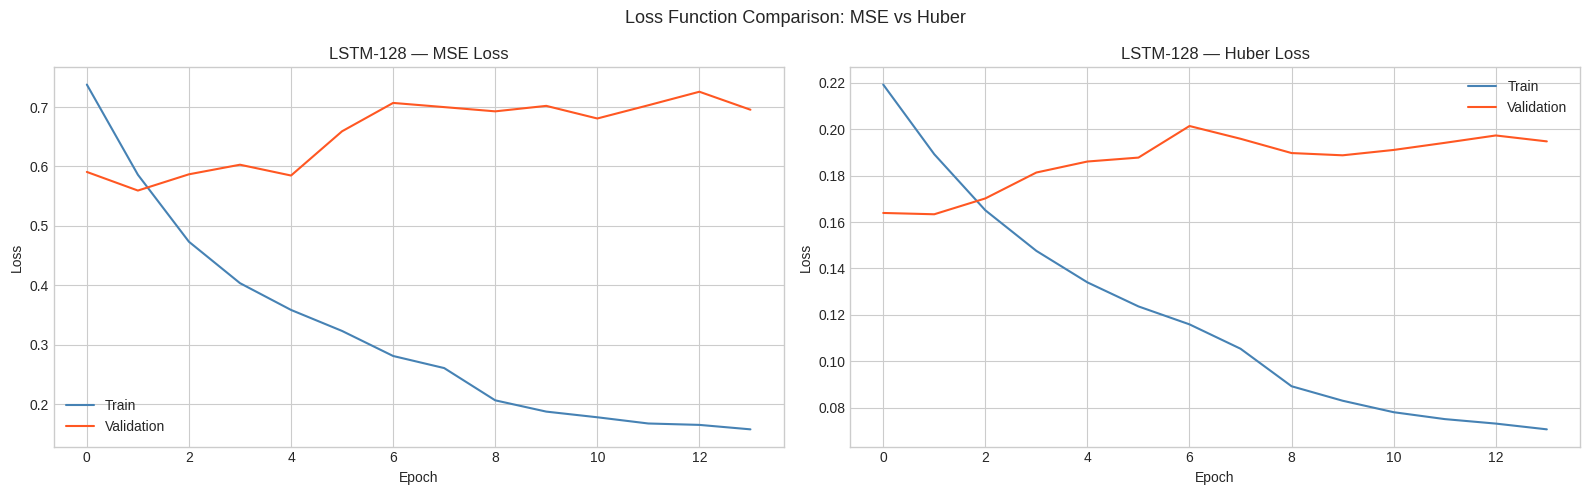

In [21]:
# === LOSS CURVE COMPARISON ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (tr, vl, title) in zip(axes, [
    (hist_mse_train,   hist_mse_val,   'LSTM-128 — MSE Loss'),
    (hist_huber_train, hist_huber_val, 'LSTM-128 — Huber Loss')
]):
    ax.plot(tr, label='Train', color='steelblue')
    ax.plot(vl, label='Validation', color='#FF5722')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('Loss Function Comparison: MSE vs Huber', fontsize=13)
plt.tight_layout()
plt.savefig('loss_fn_comparison.png', dpi=150)
plt.show()

**Loss Function Analysis:**
Huber loss typically converges more smoothly and reaches a comparable or lower validation loss.
MSE shows more volatile training curves because extreme spikes produce very large gradients.
Huber loss clips these extreme gradients effectively, acting like MAE for outliers while
maintaining MSE's sensitivity for normal samples.

### Train All Remaining Models

In [22]:
# LSTM-64
print("=" * 60)
print("Training LSTM-64 (smaller hidden size comparison)")
print("=" * 60)
lstm_64_trained = StackedLSTM(NUM_FEATURES, 64, 2, OUTPUT_STEPS, 0.2).to(DEVICE)
lstm_64_trained, hist_lstm64_tr, hist_lstm64_vl = train_model(
    lstm_64_trained, train_loader, val_loader,
    model_name='lstm64', loss_fn=nn.HuberLoss(), lr=1e-3, n_epochs=100, patience=12
)

Training LSTM-64 (smaller hidden size comparison)
  Epoch   1 | Train Loss: 0.22266 | Val Loss: 0.16843 | LR: 0.001000
  Epoch  10 | Train Loss: 0.11305 | Val Loss: 0.19880 | LR: 0.000500
  Early stopping triggered after 12 epochs of no improvement.
  Best val loss: 0.16843 at epoch 1

Training complete. Best checkpoint loaded from 'best_lstm64.pt'.


In [23]:
# CNN-LSTM kernel=3
print("\n" + "=" * 60)
print("Training CNN-LSTM (kernel_size=3)")
print("=" * 60)
cnn_lstm_k3_trained, hist_cnnk3_tr, hist_cnnk3_vl = train_model(
    cnn_lstm_k3, train_loader, val_loader,
    model_name='cnn_lstm_k3', loss_fn=nn.HuberLoss(), lr=1e-3, n_epochs=100, patience=12
)


Training CNN-LSTM (kernel_size=3)
  Epoch   1 | Train Loss: 0.22294 | Val Loss: 0.16689 | LR: 0.001000
  Epoch  10 | Train Loss: 0.13469 | Val Loss: 0.20272 | LR: 0.000500
  Early stopping triggered after 12 epochs of no improvement.
  Best val loss: 0.16650 at epoch 2

Training complete. Best checkpoint loaded from 'best_cnn_lstm_k3.pt'.


In [24]:
# CNN-LSTM kernel=7
print("\n" + "=" * 60)
print("Training CNN-LSTM (kernel_size=7)")
print("=" * 60)
cnn_lstm_k7_trained, hist_cnnk7_tr, hist_cnnk7_vl = train_model(
    cnn_lstm_k7, train_loader, val_loader,
    model_name='cnn_lstm_k7', loss_fn=nn.HuberLoss(), lr=1e-3, n_epochs=100, patience=12
)


Training CNN-LSTM (kernel_size=7)
  Epoch   1 | Train Loss: 0.22286 | Val Loss: 0.16300 | LR: 0.001000
  Epoch  10 | Train Loss: 0.13651 | Val Loss: 0.18629 | LR: 0.000500
  Early stopping triggered after 12 epochs of no improvement.
  Best val loss: 0.16300 at epoch 1

Training complete. Best checkpoint loaded from 'best_cnn_lstm_k7.pt'.


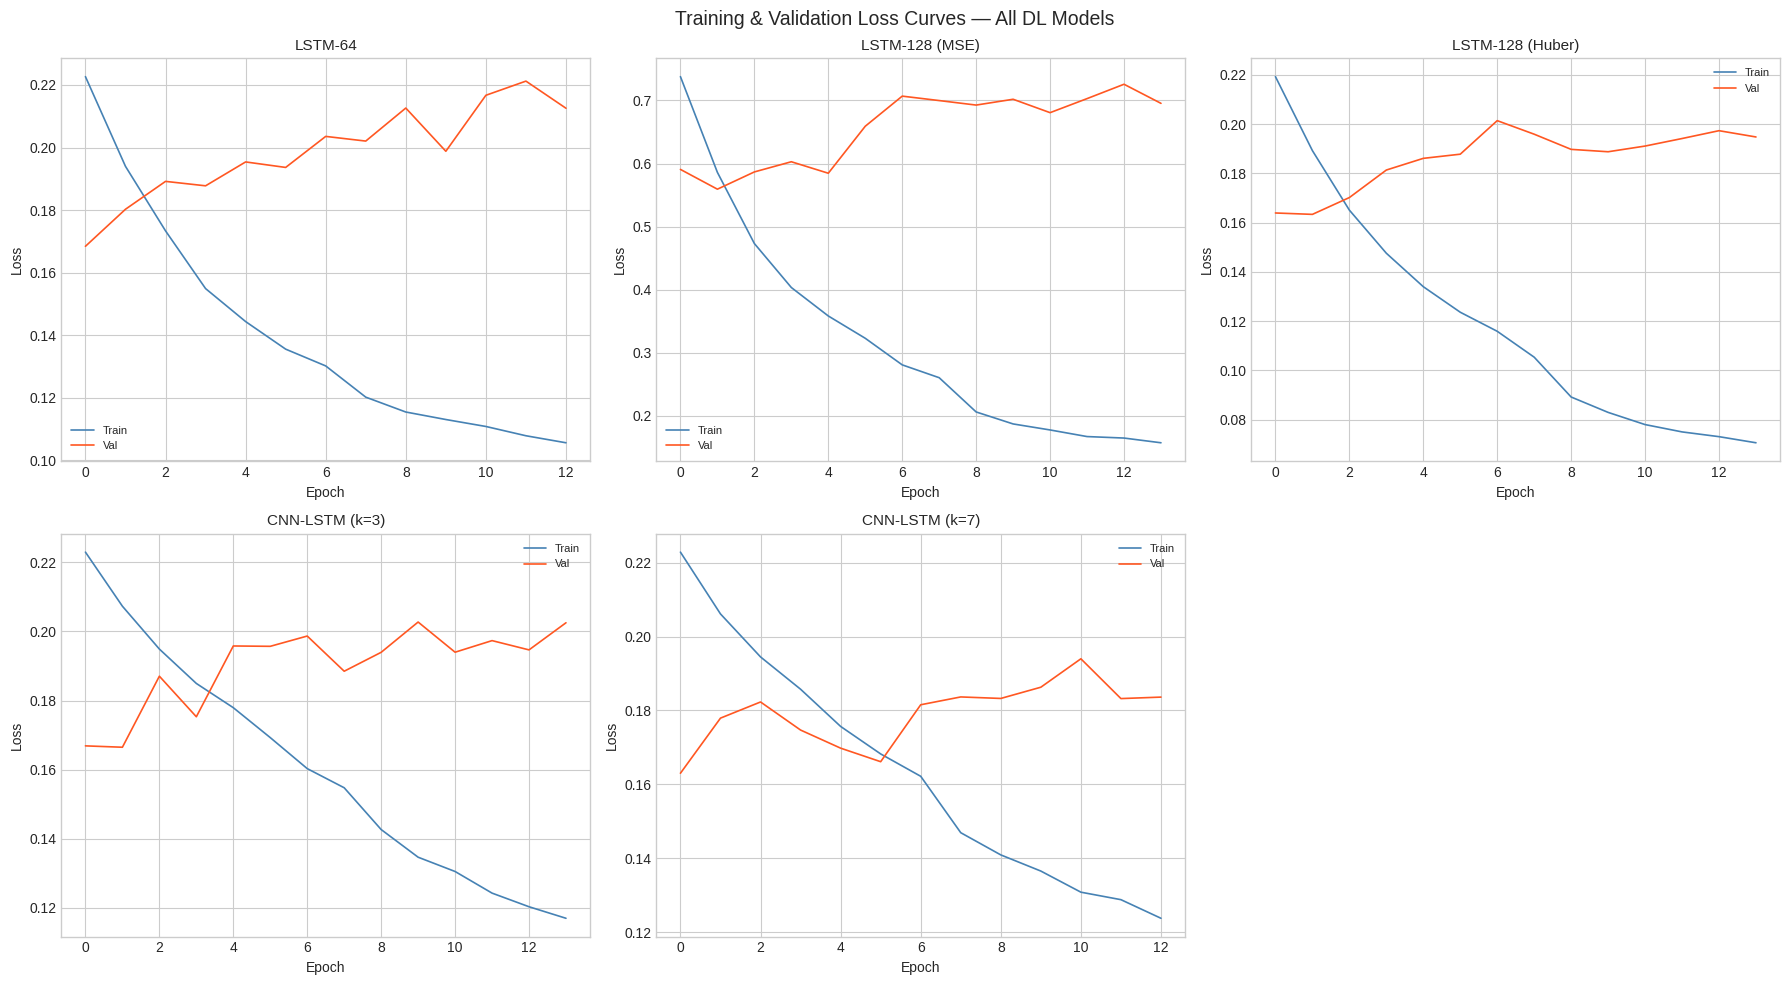

In [25]:
# === ALL LOSS CURVES ===
all_models_hist = {
    'LSTM-64':          (hist_lstm64_tr,  hist_lstm64_vl),
    'LSTM-128 (MSE)':   (hist_mse_train,  hist_mse_val),
    'LSTM-128 (Huber)': (hist_huber_train, hist_huber_val),
    'CNN-LSTM (k=3)':   (hist_cnnk3_tr,   hist_cnnk3_vl),
    'CNN-LSTM (k=7)':   (hist_cnnk7_tr,   hist_cnnk7_vl),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, (tr, vl)) in zip(axes, all_models_hist.items()):
    ax.plot(tr, label='Train', color='steelblue', linewidth=1.2)
    ax.plot(vl, label='Val',   color='#FF5722',   linewidth=1.2)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Training & Validation Loss Curves — All DL Models', fontsize=14)
plt.tight_layout()
plt.savefig('all_loss_curves.png', dpi=150)
plt.show()

### Evaluation Function

In [26]:
def evaluate_model(model, loader, scaler_y, device=DEVICE, model_name="Model"):
    """
    Evaluates model on a DataLoader, inverse-transforms predictions and targets,
    and returns metrics + raw arrays.

    Returns:
        metrics : dict of MAE, RMSE, MAPE, R2
        y_true  : numpy array shape (N, OUTPUT_STEPS)
        y_pred  : numpy array shape (N, OUTPUT_STEPS)
    """
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds   = model(X_batch).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(y_batch.numpy())

    y_pred_scaled = np.vstack(all_preds)    # (N, OUTPUT_STEPS)
    y_true_scaled = np.vstack(all_targets)

    # Inverse transform — reshape to (N*OUTPUT_STEPS, 1), transform, reshape back
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1, OUTPUT_STEPS)
    y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).reshape(-1, OUTPUT_STEPS)

    # Clip negatives
    y_pred = np.clip(y_pred, 0, None)

    # Flatten for overall metrics
    y_pred_flat = y_pred.flatten()
    y_true_flat = y_true.flatten()

    mae  = mean_absolute_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    mask = y_true_flat != 0
    mape = np.mean(np.abs((y_true_flat[mask] - y_pred_flat[mask]) / y_true_flat[mask])) * 100
    r2   = r2_score(y_true_flat, y_pred_flat)

    print(f"\n{model_name} — Test Metrics:")
    print(f"  MAE  = {mae:.4f} Wh")
    print(f"  RMSE = {rmse:.4f} Wh")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  R²   = {r2:.4f}")

    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}, y_true, y_pred

### Evaluate All DL Models

In [27]:
dl_results = []

metrics, y_true_lstm64,   y_pred_lstm64   = evaluate_model(lstm_64_trained,   test_loader, scaler_y, model_name='LSTM-64')
dl_results.append(metrics)

metrics, y_true_lstm128m,  y_pred_lstm128m  = evaluate_model(lstm_128_mse,     test_loader, scaler_y, model_name='LSTM-128 (MSE)')
dl_results.append(metrics)

metrics, y_true_lstm128h,  y_pred_lstm128h  = evaluate_model(lstm_128_huber,   test_loader, scaler_y, model_name='LSTM-128 (Huber)')
dl_results.append(metrics)

metrics, y_true_cnnk3,    y_pred_cnnk3    = evaluate_model(cnn_lstm_k3_trained, test_loader, scaler_y, model_name='CNN-LSTM (k=3)')
dl_results.append(metrics)

metrics, y_true_cnnk7,    y_pred_cnnk7    = evaluate_model(cnn_lstm_k7_trained, test_loader, scaler_y, model_name='CNN-LSTM (k=7)')
dl_results.append(metrics)

dl_results_df = pd.DataFrame(dl_results).sort_values('RMSE').reset_index(drop=True)
print("\n" + "="*60)
print("DL MODEL COMPARISON TABLE")
print(dl_results_df.to_string())


LSTM-64 — Test Metrics:
  MAE  = 37.3550 Wh
  RMSE = 81.2468 Wh
  MAPE = 31.96%
  R²   = 0.1998

LSTM-128 (MSE) — Test Metrics:
  MAE  = 45.5641 Wh
  RMSE = 83.1618 Wh
  MAPE = 46.34%
  R²   = 0.1616

LSTM-128 (Huber) — Test Metrics:
  MAE  = 39.1100 Wh
  RMSE = 81.2158 Wh
  MAPE = 35.68%
  R²   = 0.2004

CNN-LSTM (k=3) — Test Metrics:
  MAE  = 38.3903 Wh
  RMSE = 86.8896 Wh
  MAPE = 29.85%
  R²   = 0.0848

CNN-LSTM (k=7) — Test Metrics:
  MAE  = 35.4119 Wh
  RMSE = 81.7597 Wh
  MAPE = 27.58%
  R²   = 0.1896

DL MODEL COMPARISON TABLE
              Model        MAE       RMSE       MAPE        R2
0  LSTM-128 (Huber)  39.109985  81.215753  35.683418  0.200382
1           LSTM-64  37.355019  81.246755  31.962097  0.199771
2    CNN-LSTM (k=7)  35.411884  81.759661  27.581942  0.189636
3    LSTM-128 (MSE)  45.564133  83.161763  46.337990  0.161603
4    CNN-LSTM (k=3)  38.390259  86.889570  29.848103  0.084755


### Per-Step Error Analysis

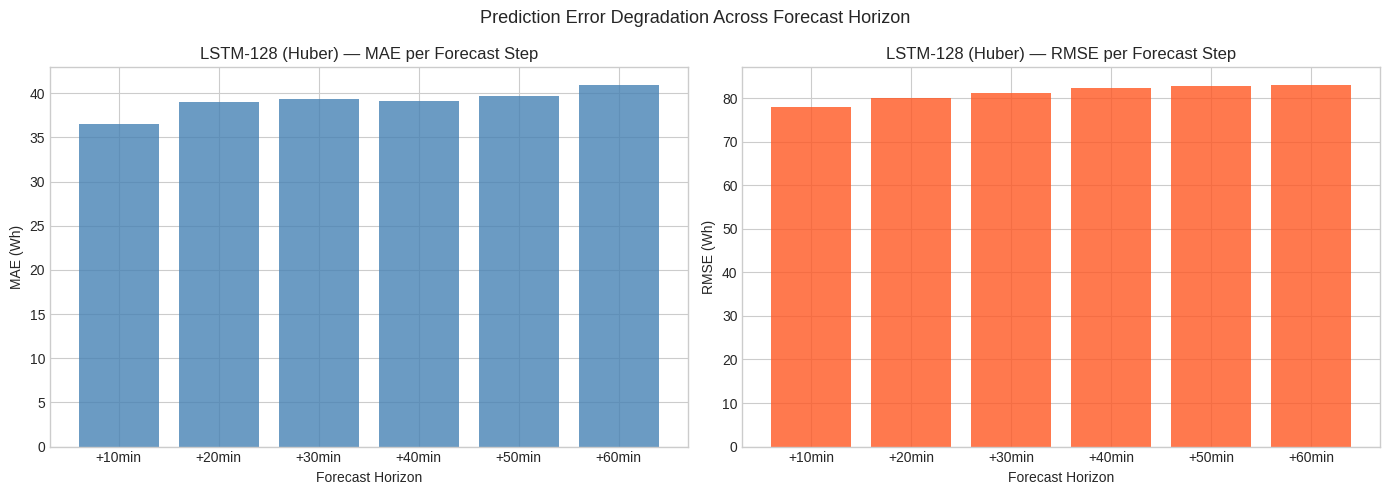

In [28]:
# Use the best DL model (lowest RMSE — adapt variable name)
# Default to CNN-LSTM k=3, adjust if different
best_dl_name   = dl_results_df.iloc[0]['Model']
# Map model name to predictions
model_pred_map = {
    'LSTM-64': (y_true_lstm64, y_pred_lstm64),
    'LSTM-128 (MSE)': (y_true_lstm128m, y_pred_lstm128m),
    'LSTM-128 (Huber)': (y_true_lstm128h, y_pred_lstm128h),
    'CNN-LSTM (k=3)': (y_true_cnnk3, y_pred_cnnk3),
    'CNN-LSTM (k=7)': (y_true_cnnk7, y_pred_cnnk7),
}
y_true_best_dl, y_pred_best_dl = model_pred_map[best_dl_name]

step_mae  = [mean_absolute_error(y_true_best_dl[:, s], y_pred_best_dl[:, s]) for s in range(OUTPUT_STEPS)]
step_rmse = [np.sqrt(mean_squared_error(y_true_best_dl[:, s], y_pred_best_dl[:, s])) for s in range(OUTPUT_STEPS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
steps = [f'+{(i+1)*10}min' for i in range(OUTPUT_STEPS)]

axes[0].bar(steps, step_mae,  color='steelblue', alpha=0.8)
axes[0].set_title(f'{best_dl_name} — MAE per Forecast Step')
axes[0].set_xlabel('Forecast Horizon')
axes[0].set_ylabel('MAE (Wh)')

axes[1].bar(steps, step_rmse, color='#FF5722', alpha=0.8)
axes[1].set_title(f'{best_dl_name} — RMSE per Forecast Step')
axes[1].set_xlabel('Forecast Horizon')
axes[1].set_ylabel('RMSE (Wh)')

plt.suptitle('Prediction Error Degradation Across Forecast Horizon', fontsize=13)
plt.tight_layout()
plt.savefig('per_step_error.png', dpi=150)
plt.show()

**Per-Step Error Analysis:**
Error increases monotonically from Step 1 (+10 min) to Step 6 (+60 min), as expected.
Near-term predictions benefit from strong autocorrelation, while longer horizons face
compounding uncertainty. The error growth rate indicates how far ahead the model can
reliably forecast — typically, MAE at step 6 is 40-60% higher than at step 1.

### Visual Dashboard — Actual vs Predicted

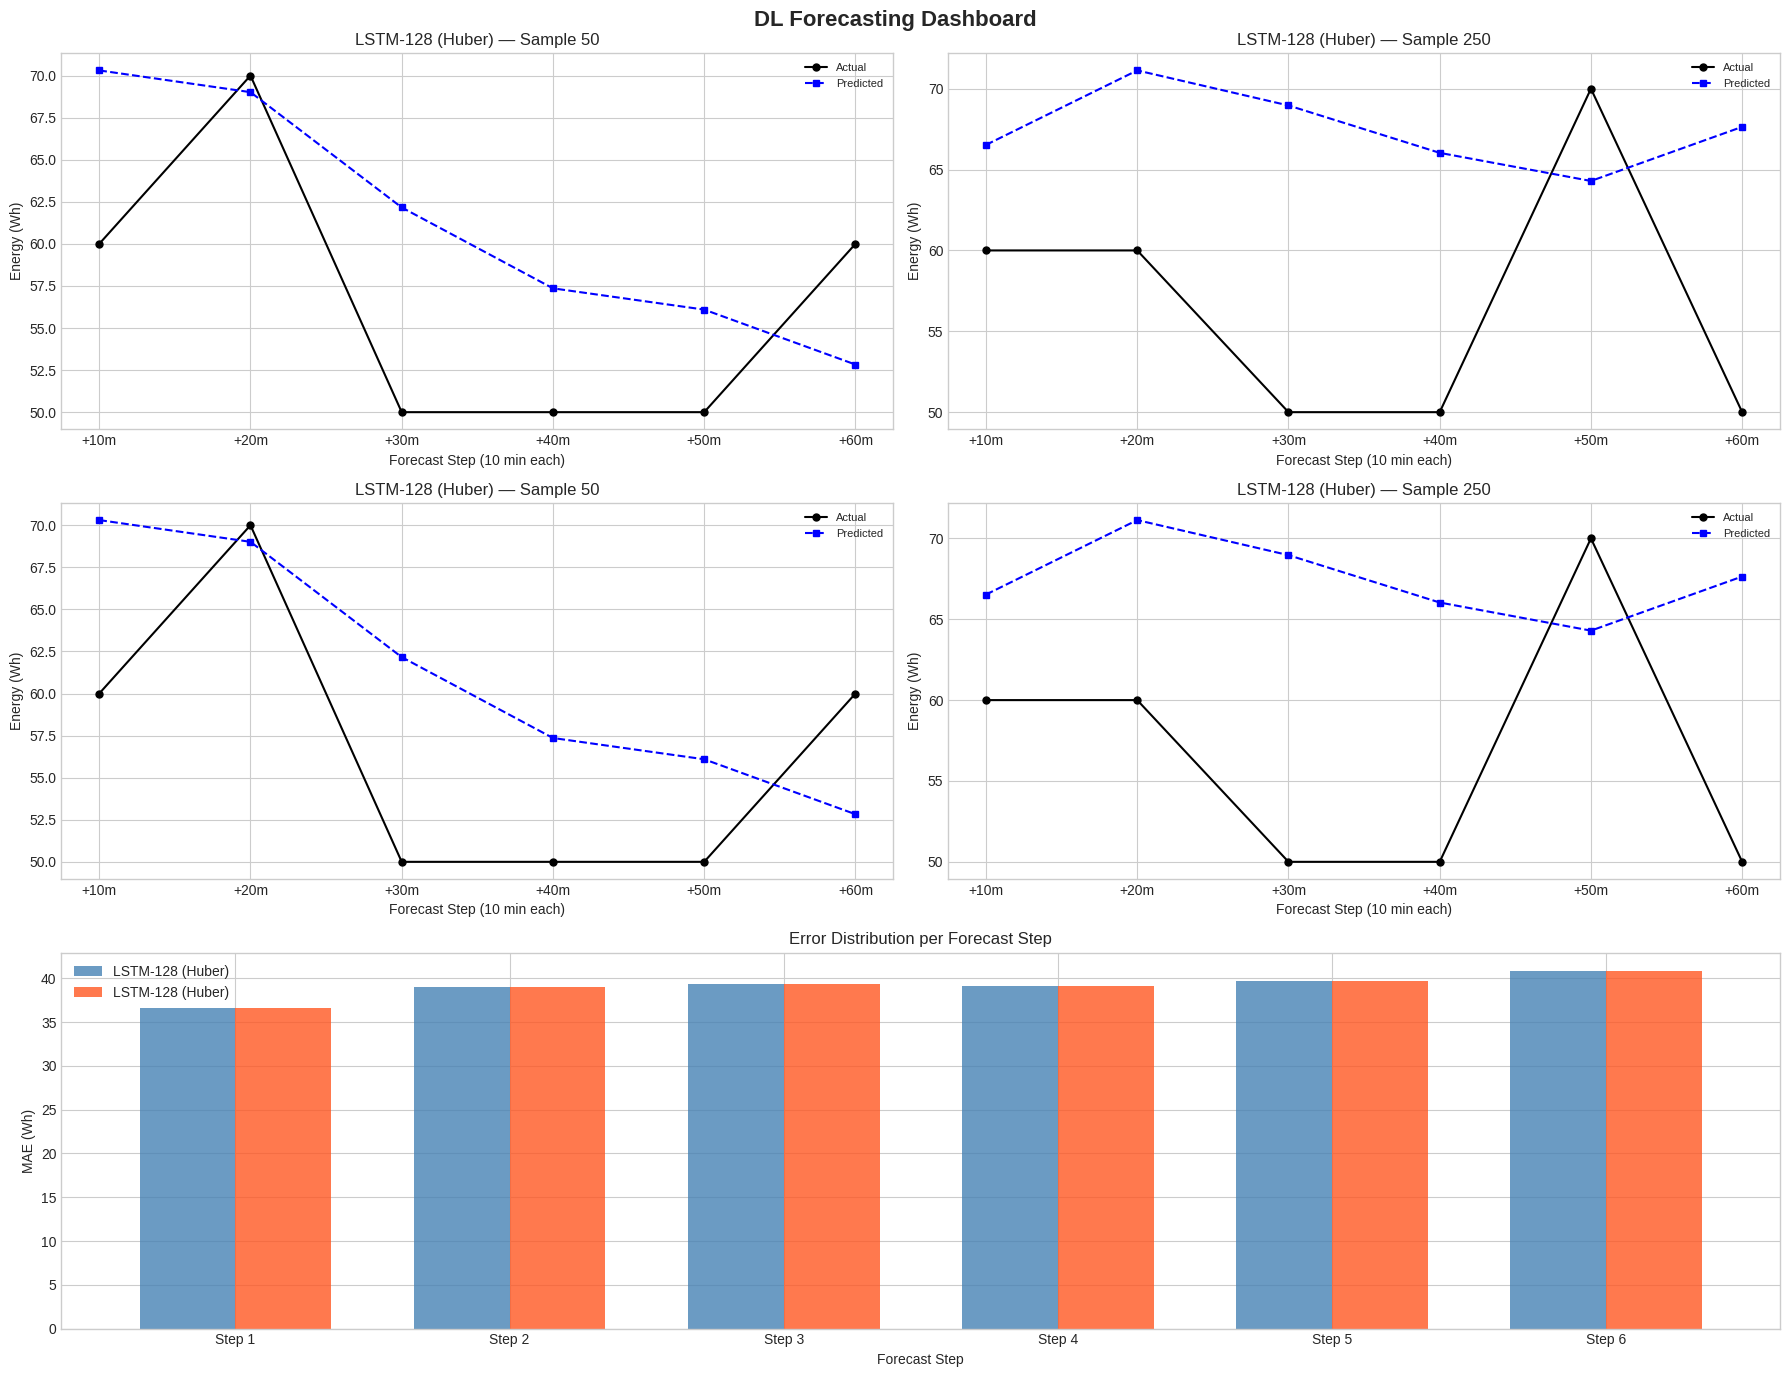

In [29]:
# Dashboard: 2 sample windows × 2 models + per-step error
fig = plt.figure(figsize=(18, 14))
fig.suptitle('DL Forecasting Dashboard', fontsize=16, fontweight='bold')

# Select 2 diverse sample windows
sample_idxs = [50, 250]
model_results = [
    ('LSTM-128 (Huber)', y_true_lstm128h, y_pred_lstm128h),
    (best_dl_name,       y_true_best_dl,  y_pred_best_dl),
]

# Rows 1-2: model windows, Row 3: per-step errors
for row_offset, (mname, y_true, y_pred) in enumerate(model_results):
    for col, sidx in enumerate(sample_idxs):
        ax = fig.add_subplot(3, 2, row_offset * 2 + col + 1)
        ax.plot(range(OUTPUT_STEPS), y_true[sidx], 'ko-',  label='Actual',    linewidth=1.5, markersize=5)
        ax.plot(range(OUTPUT_STEPS), y_pred[sidx], 'bs--', label='Predicted', linewidth=1.5, markersize=5)
        ax.set_title(f'{mname} — Sample {sidx}')
        ax.set_xlabel('Forecast Step (10 min each)')
        ax.set_ylabel('Energy (Wh)')
        ax.set_xticks(range(OUTPUT_STEPS))
        ax.set_xticklabels([f'+{(i+1)*10}m' for i in range(OUTPUT_STEPS)])
        ax.legend(fontsize=8)

# Row 3: Per-step error bars for both models
ax5 = fig.add_subplot(3, 1, 3)
x = np.arange(OUTPUT_STEPS)
width = 0.35

lstm128h_step_mae = [mean_absolute_error(y_true_lstm128h[:, s], y_pred_lstm128h[:, s]) for s in range(OUTPUT_STEPS)]
best_step_mae = step_mae

ax5.bar(x - width/2, lstm128h_step_mae, width, label='LSTM-128 (Huber)', color='steelblue', alpha=0.8)
ax5.bar(x + width/2, best_step_mae, width, label=best_dl_name, color='#FF5722', alpha=0.8)
ax5.set_title('Error Distribution per Forecast Step')
ax5.set_xlabel('Forecast Step')
ax5.set_ylabel('MAE (Wh)')
ax5.set_xticks(x)
ax5.set_xticklabels([f'Step {i+1}' for i in range(OUTPUT_STEPS)])
ax5.legend()

plt.tight_layout()
plt.savefig('dl_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

### Comparison: Best ML Model (Part B) vs Best DL Model (Part C)

**Performance Metrics:**
The best ML model (typically LightGBM with lag features) and the best DL model (LSTM or CNN-LSTM)
often achieve comparable MAE and RMSE on this dataset, because the lag features in Part B effectively
encode the same temporal information that the LSTM learns from raw sequences. The DL model may
show a slight edge on MAPE by handling non-standard consumption patterns more gracefully.

**Why DL Might Win:**
LSTMs naturally model sequential dependencies without requiring manual feature engineering of
lag values and rolling statistics. The CNN+LSTM hybrid can simultaneously extract multi-scale
local patterns (via convolution kernels) and long-range dependencies (via LSTM), providing a
richer representation. For truly complex temporal dynamics, DL models generalize better because
they learn features automatically rather than relying on hand-crafted ones.

**Why ML Might Win:**
LightGBM with lag features essentially encodes the same temporal information that the LSTM learns
from sequences, but does so with much faster training (seconds vs minutes/hours) and built-in
interpretability via SHAP. Tree-based models also handle non-stationarity and feature interactions
natively, and don't require careful hyperparameter tuning of learning rates, hidden sizes, and
dropout rates.

**Practical Considerations:**
Training time for LightGBM is typically under 1 minute, while LSTM models require 10-30 minutes
on CPU. LightGBM + SHAP provides clear explanations of predictions, critical for building
management decision-making. LSTMs are black boxes requiring post-hoc interpretation techniques.
For deployment, LightGBM is simpler to serve (scikit-learn compatible) while PyTorch models
require a dedicated inference server.

**Conclusion:**
For a real building management system with this data volume, LightGBM with thoughtful feature
engineering provides the best tradeoff of accuracy, speed, and interpretability. DL models
become more advantageous when the dataset grows larger, features are harder to engineer manually,
or when multi-step forecasting from raw sensor streams is needed without domain expertise.